In [1]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

In [2]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

**Artificial ground-truth mask**


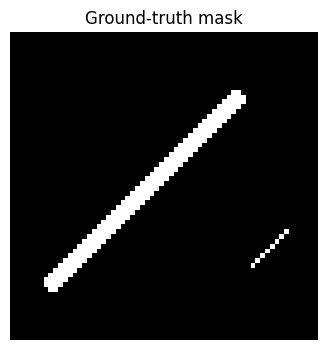

Foreground pixels: 210
Background pixels: 3886


In [3]:
HEIGHT = 64
WIDTH = 64

ground_truth = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

cv2.line(ground_truth, (8, 52), (47, 13), color=1, thickness=2)
cv2.line(ground_truth, (50, 48), (57, 41), color=1, thickness=1)

plt.figure(figsize=(4, 4))
plt.imshow(ground_truth, cmap="gray", vmin=0, vmax=1,)

plt.title("Ground-truth mask")
plt.axis("off")
plt.show()

print("Foreground pixels:",ground_truth.sum())
print("Background pixels:",ground_truth.size - ground_truth.sum())

**5 types of prediction**


In [4]:
def shift_mask(mask, dx=0, dy=0):
    transform = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])
    return cv2.warpAffine(
        mask, transform,
        (mask.shape[1], mask.shape[0]),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

In [5]:
perfect_prediction = ground_truth.copy()
empty_prediction = np.zeros_like(ground_truth)
shifted_prediction = shift_mask(ground_truth, dx=3)

tiny_crack_missed = ground_truth.copy()
tiny_crack_missed[38:51, 48:60] = 0

background_false_positive = ground_truth.copy()
background_false_positive[5:18, 45:59] = 1

predictions = {
    "perfect": perfect_prediction,
    "empty": empty_prediction,
    "shifted": shifted_prediction,
    "tiny_missed": tiny_crack_missed,
    "background_fp": background_false_positive
}

**Normalized polygon to raster mask**


In [6]:
polygon_normalized = np.array([
        [0.10, 0.75],
        [0.18, 0.68],
        [0.32, 0.60],
        [0.48, 0.42],
        [0.65, 0.28],
        [0.69, 0.32],
        [0.52, 0.48],
        [0.35, 0.66],
        [0.20, 0.73],
        [0.12, 0.79]
],dtype=np.float32)

polygon_pixels = np.column_stack([
    polygon_normalized[:, 0] * (WIDTH - 1),
    polygon_normalized[:, 1] * (HEIGHT - 1)
])

polygon_pixels = polygon_pixels.round().astype(np.int32)
polygon_mask = np.zeros((HEIGHT, WIDTH), dtype=np.uint8)

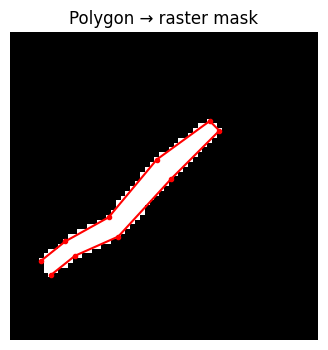

In [7]:
cv2.fillPoly(polygon_mask, [polygon_pixels], color=1)

plt.figure(figsize=(4, 4))
plt.imshow(polygon_mask, cmap="gray")
plt.plot(polygon_pixels[:, 0], polygon_pixels[:, 1], "r.-")
plt.title("Polygon → raster mask")
plt.axis("off")
plt.show()

**Connected components**


Connected components: 2


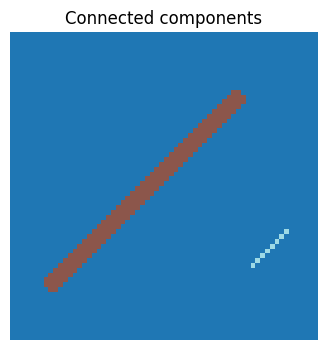

In [8]:
number_of_labels, component_map = cv2.connectedComponents(ground_truth, connectivity=8)

number_of_components = number_of_labels - 1
print("Connected components:", number_of_components)

plt.figure(figsize=(4, 4))
plt.imshow(component_map, cmap="tab20",)

plt.title("Connected components")
plt.axis("off")
plt.show()

**Sigmoid and softmax experiment**


In [9]:
binary_logits = torch.tensor([ -4.0, 0.0, 4.0])
binary_probabilities = torch.sigmoid(binary_logits)

binary_predictions = (binary_probabilities >= 0.50).to(torch.uint8)

print("Logits:", binary_logits)
print("Probabilities:", binary_probabilities.round(decimals=4))
print("Predicted classes:",binary_predictions)

Logits: tensor([-4.,  0.,  4.])
Probabilities: tensor([0.0180, 0.5000, 0.9820])
Predicted classes: tensor([0, 1, 1], dtype=torch.uint8)


In [10]:
multiclass_logits = torch.tensor([
    [3.0, 1.0, -1.0],
    [0.5, 2.5, 1.0],
])

multiclass_probabilities = torch.softmax(multiclass_logits, dim=1)
multiclass_predictions = multiclass_probabilities.argmax(dim=1)

print(multiclass_probabilities.round(decimals=4))
print("Predicted class IDs:", multiclass_predictions)

tensor([[0.8668, 0.1173, 0.0159],
        [0.0996, 0.7361, 0.1643]])
Predicted class IDs: tensor([0, 1])


**Mask resizing**

In [11]:
small_mask = torch.tensor([
    [0, 0, 0, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 0, 0, 0]
], dtype=torch.float32)[None][None]

nearest_mask = F.interpolate(
    small_mask, size=(12, 12), mode="nearest"
)

bilinear_mask = F.interpolate(
    small_mask, size=(12, 12), mode="bilinear", align_corners=False
)

print("Nearest unique values:", torch.unique(nearest_mask))
print("Bilinear unique values:", torch.unique(bilinear_mask))

Nearest unique values: tensor([0., 1.])
Bilinear unique values: tensor([0.0000, 0.1111, 0.1111, 0.1111, 0.2222, 0.2222, 0.2222, 0.3333, 0.3333,
        0.4444, 0.4444, 0.4444, 0.6667, 0.6667, 1.0000])


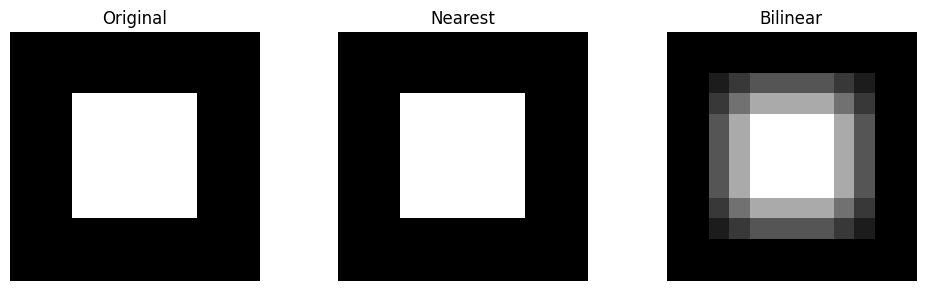

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3),)

axes[0].imshow(small_mask[0, 0], cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(nearest_mask[0, 0], cmap="gray")
axes[1].set_title("Nearest")

axes[2].imshow(bilinear_mask[0, 0], cmap="gray")
axes[2].set_title("Bilinear")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

**Binary segmentation metrics**

$$\text{Pixel Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{FP} + \text{FN} + \text{TN}}$$

$$ \text{Precision} = \frac{TP}{TP+FP} $$ $$ \text{Recall} = \frac{TP}{TP+FN} $$ $$ \text{IoU} = \frac{TP}{TP+FP+FN} $$ $$ \text{Dice} = \frac{2TP}{2TP+FP+FN} $$

For binary mask:

$$\text{Dice} = \frac{2 \cdot \text{IoU}}{1 + \text{IoU}}$$


**Metrics implementation**

In [13]:
def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan
    return float(numerator / denominator)


def binary_segmentation_metrics(prediction, target):
    prediction = np.asarray(prediction).astype(bool)
    target = np.asarray(target).astype(bool)
    
    true_positive = np.logical_and(prediction, target).sum()
    false_positive = np.logical_and(prediction, ~target).sum()
    false_negative = np.logical_and(~prediction, target).sum()
    true_negative = np.logical_and(~prediction, ~target).sum()
    
    total = (
        true_positive+ false_positive + false_negative + true_negative
    )
    
    return {
        "tp": int(true_positive),
        "fp": int(false_positive),
        "fn": int(false_negative),
        "tn": int(true_negative),
        
        "pixel_accuracy" : safe_divide(true_positive + true_negative, total),
        "precision" : safe_divide(true_positive, true_positive + false_positive),
        "recall" : safe_divide(true_positive, true_positive + false_positive),
        
        "iou" : safe_divide(true_positive, true_negative + false_positive + false_negative),
        "dice" : safe_divide(2 * true_positive, 2 * true_positive + false_positive + false_negative)
    }

In [14]:
metric_rows = []

for name, prediction in (predictions.items()):
    metrics = binary_segmentation_metrics(prediction, ground_truth)

    metric_rows.append({
        "case": name,
        **metrics,
    })


metrics_dataframe = pd.DataFrame(metric_rows)
display(metrics_dataframe.round(4))

,case,tp,fp,fn,tn,pixel_accuracy,precision,recall,iou,dice
0,perfect,210,0,0,3886,1.0000,1.0000,1.0000,0.0540,1.0000
1,empty,0,0,210,3886,0.9487,NaN,NaN,0.0000,0.0000
2,shifted,78,132,132,3754,0.9355,0.3714,0.3714,0.0194,0.3714
3,tiny_missed,202,0,8,3886,0.9980,1.0000,1.0000,0.0519,0.9806
4,background_fp,210,166,0,3720,0.9595,0.5585,0.5585,0.0540,0.7167


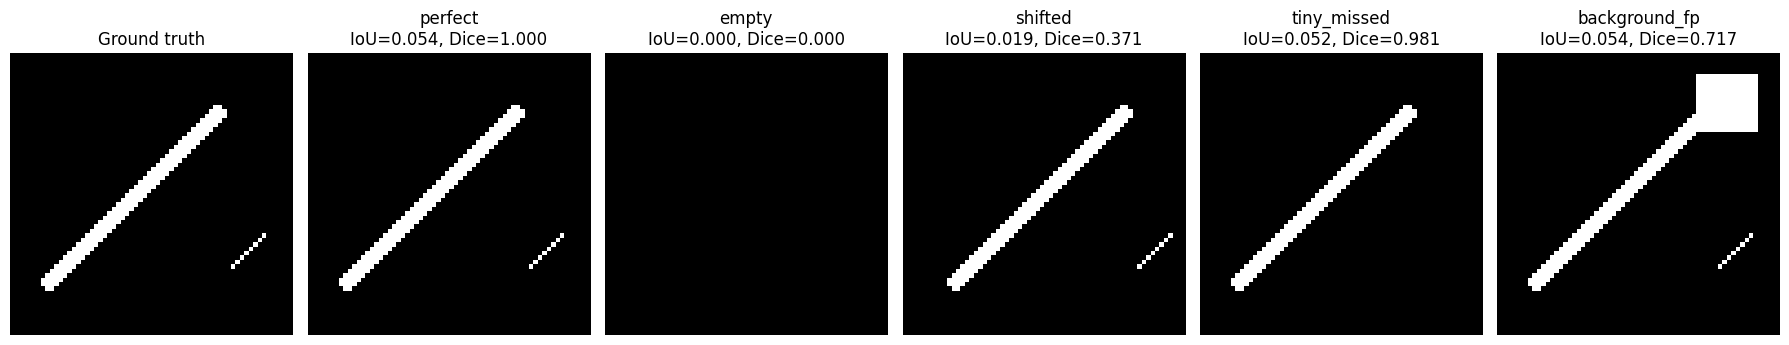

In [15]:
fig, axes = plt.subplots(1, len(predictions) + 1, figsize=(18, 4))

axes[0].imshow(
    ground_truth,
    cmap="gray",
    vmin=0,
    vmax=1,
)

axes[0].set_title("Ground truth")
axes[0].axis("off")


for axis, (name, prediction,) in zip(
    axes[1:],
    predictions.items(),
):
    metrics = binary_segmentation_metrics(prediction, ground_truth)
    axis.imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axis.set_title(
        f"{name}\n"
        f"IoU={metrics['iou']:.3f}, "
        f"Dice={metrics['dice']:.3f}"
    )
    axis.axis("off")


plt.tight_layout()
plt.show()

**Multiclass confusion matrix and per-class IoU**

In [16]:
def multiclass_confusion_matrix(prediction, target, number_of_classes, ignore_index=None):
    prediction = prediction.reshape(-1).long()
    target = prediction.reshape(-1).long()
    
    valid = (
        (target >= 0) & (target < number_of_classes)
    )
    
    if ignore_index is not None:
        valid &= (target != ignore_index)
    
    encoded = number_of_classes * target[valid] + prediction[valid]
    
    confusion_matrix = torch.bincount(encoded, minlength=(number_of_classes ** 2))
    
    return confusion_matrix.reshape(
        number_of_classes, number_of_classes
    )

In [17]:
def per_class_iou_from_confusion(confusion_matrix):
    confusion_matrix = confusion_matrix.float()
    
    true_positive = torch.diag(confusion_matrix)
    false_positive = confusion_matrix.sum(dim=0) - true_positive
    false_negative = confusion_matrix.sum(dim=1) - true_positive
    
    denominator = true_positive + false_negative + false_positive
    
    return torch.where(
        denominator > 0, true_positive / denominator, torch.nan
    )

In [18]:
target_classes = torch.tensor([
    [0, 0, 1, 1],
    [0, 1, 1, 2],
    [0, 1, 2, 2],
    [0, 0, 2, 2],
])

predicted_classes = torch.tensor([
    [0, 0, 1, 1],
    [0, 1, 0, 2],
    [0, 2, 2, 2],
    [0, 0, 1, 2],
])

class_names = ["background", "surface", "crack"]
confusion_matrix = (
    multiclass_confusion_matrix(
        predicted_classes,
        target_classes,
        number_of_classes=3,
    )
)

class_ious = per_class_iou_from_confusion(confusion_matrix)
iou_dataframe = pd.DataFrame({
    "class": class_names,
    "support": (confusion_matrix.sum(dim=1).tolist()),
    "iou": class_ious.tolist(),
})

print("Confusion matrix:\n", confusion_matrix)
display(iou_dataframe.round(4))
print("Mean IoU:", torch.nanmean(class_ious).item())

Confusion matrix:
 tensor([[7, 0, 0],
        [0, 4, 0],
        [0, 0, 5]])


,class,support,iou
0,background,7,1.0
1,surface,4,1.0
2,crack,5,1.0


Mean IoU: 1.0


**Segmentation losses**

In [19]:
def binary_dice_loss(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dim=dimensions)
    
    denominator = (probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions))
    
    dice_score = (2 * intersection + epsilon) / (denominator + epsilon)
    
    return (1 - dice_score).mean()

In [20]:
def binary_focal_loss(logits, targets, alpha=0.75, gamma=2.0):
    elementwise_bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    
    probabilities = torch.sigmoid(logits)
    
    probabilities_of_true_class = (probabilities * targets + (1 - probabilities) * (1 - targets))
    
    alpha_factor = (alpha * targets + (1 - alpha) * (1 - targets))
    
    focal_weight = (alpha_factor * (1 - probabilities_of_true_class).pow(gamma))
    
    return (focal_weight * elementwise_bce).mean()

In [21]:
def bce_dise_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    
    dice = binary_dice_loss(logits, targets)
    return bce + dice

**Loss behavior experiment**

In [22]:
target_tensor = torch.from_numpy(ground_truth).float()[None, None]

positive_pixels = target_tensor.sum()
negative_pixels = target_tensor.numel() - positive_pixels
positive_weight = negative_pixels / positive_pixels.clamp_min(1)

In [23]:
loss_rows = []

for name, prediction in (predictions.items()):
    prediction_tensor = torch.from_numpy(prediction).float()[None, None]
    
    logits = torch.where(
        prediction_tensor > 0.5,
        torch.tensor(6.0),
        torch.tensor(-6.0)
    )
    
    bce = F.binary_cross_entropy_with_logits(logits, target_tensor)
    weighted_bce = F.binary_cross_entropy_with_logits(logits, target_tensor, pos_weight=positive_weight)
    
    dice = binary_dice_loss(logits, target_tensor)
    focal = binary_focal_loss(logits, target_tensor)
    combined = bce_dise_loss(logits, target_tensor)
    
    loss_rows.append({
        "case": name,
        "bce": bce.item(),
        "weighted_bce": weighted_bce.item(),
        "dice_loss": dice.item(),
        "focal_loss": focal.item(),
        "bce_plus_dice": combined.item()
    })

loss_dataframe = pd.DataFrame(loss_rows)
display(loss_dataframe.round(4))

,case,bce,weighted_bce,dice_loss,focal_loss,bce_plus_dice
0,perfect,0.0025,0.0047,0.0236,0.0000,0.0261
1,empty,0.3101,5.6971,0.9953,0.2297,1.3054
2,shifted,0.3892,3.7761,0.6358,0.1925,1.0250
3,tiny_missed,0.0142,0.2216,0.0430,0.0087,0.0571
4,background_fp,0.2456,0.2479,0.2950,0.0605,0.5406


**Multiclass Cross-Entropy example**

In [24]:
multiclass_target = target_classes.unsqueeze(0).long()
multiclass_logits = torch.randn(1, 3, 4, 4)

cross_entropy_loss = F.cross_entropy(multiclass_logits, multiclass_target)

print("Cross-entropy loss:", cross_entropy_loss.item())

Cross-entropy loss: 1.4810622930526733


**Probability threshold sweep**

In [25]:
soft_probability = cv2.GaussianBlur(
    ground_truth.astype(np.float32),
    ksize=(9, 9),
    sigmaX=1.7
)

soft_probability /= max(soft_probability.max(),1e-6)
random_generator = np.random.default_rng(SEED)

noise = random_generator.normal(
    loc=0.0,
    scale=0.07,
    size=soft_probability.shape,
)

soft_probability = np.clip(soft_probability + noise, 0.0, 1.0)
threshold_rows = []

for threshold in np.arange(0.10, 1.00, 0.10):
    binary_prediction = (soft_probability >= threshold).astype(np.uint8)

    metrics = (
        binary_segmentation_metrics(binary_prediction, ground_truth)
    )

    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "iou": metrics["iou"],
        "dice": metrics["dice"],
    })


threshold_dataframe = pd.DataFrame(threshold_rows)
display(threshold_dataframe.round(4))

,threshold,precision,recall,iou,dice
0,0.1,0.2609,0.2609,0.0538,0.4135
1,0.2,0.4680,0.4680,0.0527,0.6327
2,0.3,0.5670,0.5670,0.0521,0.7148
3,0.4,0.6779,0.6779,0.0519,0.7953
4,0.5,0.7681,0.7681,0.0519,0.8541
5,0.6,0.9151,0.9151,0.0497,0.9194
6,0.7,0.9890,0.9890,0.0460,0.9184
7,0.8,1.0000,1.0000,0.0338,0.7791
8,0.9,1.0000,1.0000,0.0232,0.6139


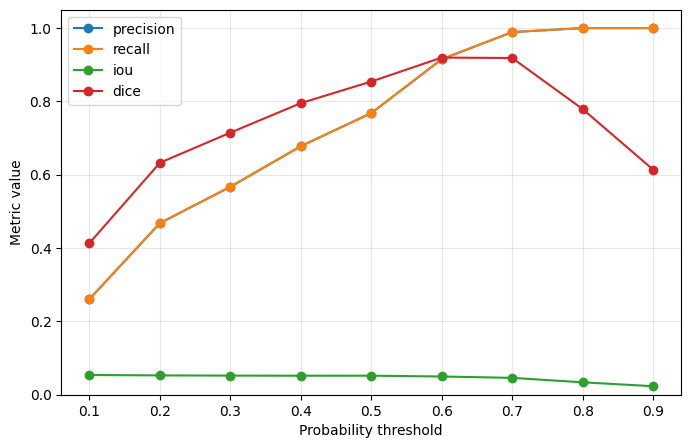

In [26]:
plt.figure(figsize=(8, 5))

for metric_name in ["precision", "recall", "iou", "dice"]:
    plt.plot(
        threshold_dataframe["threshold"],
        threshold_dataframe[metric_name],
        marker="o",
        label=metric_name,
    )

plt.xlabel("Probability threshold")
plt.ylabel("Metric value")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
best_row_index = threshold_dataframe["dice"].idxmax()
best_threshold_row = threshold_dataframe.loc[best_row_index]

print("Best threshold by Dice:", best_threshold_row["threshold"])
print("Best Dice:", best_threshold_row["dice"],)

Best threshold by Dice: 0.6
Best Dice: 0.919431279620853
